
---


# 🏛️ ***`Curse of Dimensionality in Machine Learning for Data Science`*** 📊  

## ✅ **What is the Curse of Dimensionality?**  

The **Curse of Dimensionality** refers to the **challenges that arise when working with high-dimensional data**. As the number of features (**dimensions**) increases, the data becomes **sparser**, making it difficult for Machine Learning (ML) algorithms to generalize well.  

---

## 🎯 **1. Why Does the Curse of Dimensionality Matter?**  

🔹 **As dimensions increase:**  
- **Data points become more sparse** → Reduces model performance.  
- **Distance-based models fail** → Euclidean distance becomes less meaningful.  
- **Computational cost skyrockets** → More features require more processing power.  
- **Overfitting increases** → More dimensions mean the model learns noise instead of patterns.  

---

## 📊 **2. How Curse of Dimensionality Affects ML Models**  

| **ML Algorithm** | **Effect of High Dimensions** |
|------------------|--------------------------------|
| **K-Nearest Neighbors (KNN)** | Distance between points becomes less meaningful. |
| **K-Means Clustering** | Poor cluster separation due to sparsity. |
| **Principal Component Analysis (PCA)** | Needs more computation with increasing dimensions. |
| **Linear Regression** | Leads to multicollinearity and overfitting. |
| **Neural Networks** | Requires more data to generalize well. |

---

## 📏 **3. How to Detect the Curse of Dimensionality?**  

### **📉 1. Increase in Distance Between Points**
In high dimensions, **all points tend to be equidistant**, making distance-based models ineffective.

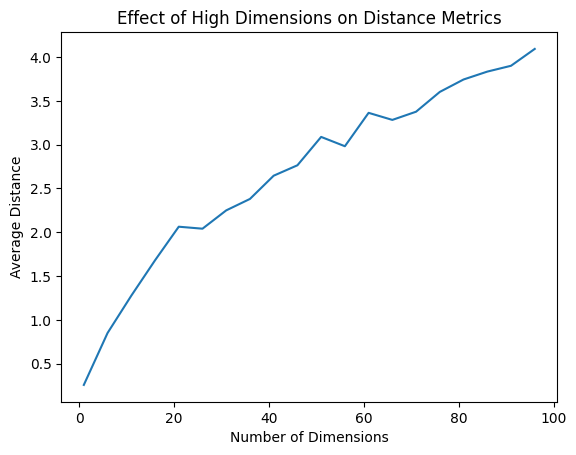

In [1]:
import numpy as np
import matplotlib.pyplot as plt

dims = np.arange(1, 100, 5)  # Dimensions from 1 to 100
samples = 1000

avg_distances = []
for d in dims:
    points = np.random.rand(samples, d)  # Generate random points
    pairwise_dist = np.linalg.norm(points[0] - points[1:], axis=1)  # Compute distances
    avg_distances.append(np.mean(pairwise_dist))

plt.plot(dims, avg_distances)
plt.xlabel("Number of Dimensions")
plt.ylabel("Average Distance")
plt.title("Effect of High Dimensions on Distance Metrics")
plt.show() 


📌 **Observation:**  
- As dimensions increase, **distance values become similar**, making it harder to distinguish between close and far points.

---

### **📊 2. Sparsity of Data in High Dimensions**
📌 **High-dimensional data tends to spread out, making meaningful clusters difficult to find.** 

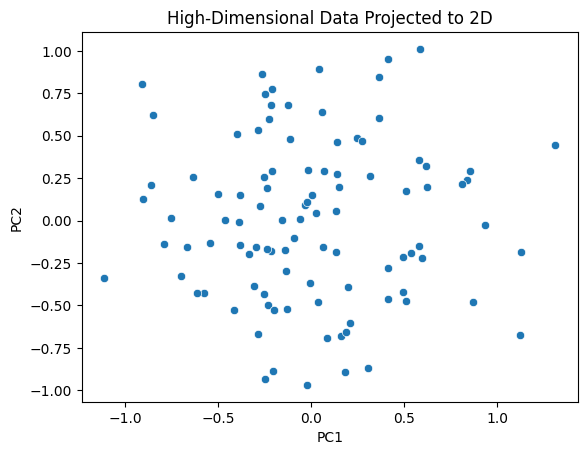

In [2]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

# Generate High-Dimensional Data
np.random.seed(42)
data = np.random.rand(100, 50)  # 100 samples, 50 features

# Reduce to 2D using PCA
pca = PCA(n_components=2)
data_2D = pca.fit_transform(data)

# Convert to DataFrame for Visualization
df = pd.DataFrame(data_2D, columns=['PC1', 'PC2'])

# Scatter Plot
sns.scatterplot(x='PC1', y='PC2', data=df)
plt.title("High-Dimensional Data Projected to 2D")
plt.show()

📌 **Observation:**  
- High-dimensional data **looks unstructured in lower dimensions**, making clustering and classification harder.

---

## 🛠 **4. How to Overcome the Curse of Dimensionality?**  

### ✅ **1. Feature Selection (Keeping Only Relevant Features)**  
Feature selection helps reduce dimensions by keeping only the **most important features**.

**🔹 Techniques:**
- **Variance Threshold:** Removes features with very low variance.  
- **Correlation Matrix:** Drops highly correlated features.  
- **Chi-Square Test:** Selects features with high association to target.  
- **Recursive Feature Elimination (RFE):** Iteratively removes least important features.  

In [3]:
from sklearn.feature_selection import SelectKBest, f_classif

# Sample Data
X = np.random.rand(100, 10)  # 100 samples, 10 features
y = np.random.randint(0, 2, 100)  # Binary target variable

# Select top 5 features using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

print("Selected Features Shape:", X_selected.shape)

Selected Features Shape: (100, 5)




📌 **Effect:**  
- Reduces dimensions while preserving information.  

---

### ✅ **2. Dimensionality Reduction (PCA, t-SNE, LDA, Autoencoders)**  

#### **🔹 Principal Component Analysis (PCA)**
- Converts high-dimensional data into **principal components** that capture maximum variance.

In [4]:
from sklearn.decomposition import PCA

# Reduce to 2 Principal Components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.15163602 0.1355118 ]



📌 **Effect:**  
- Reduces dimensions while retaining most information.

---

#### **🔹 t-SNE (for visualization)**
- Captures **non-linear relationships** in high-dimensional data.

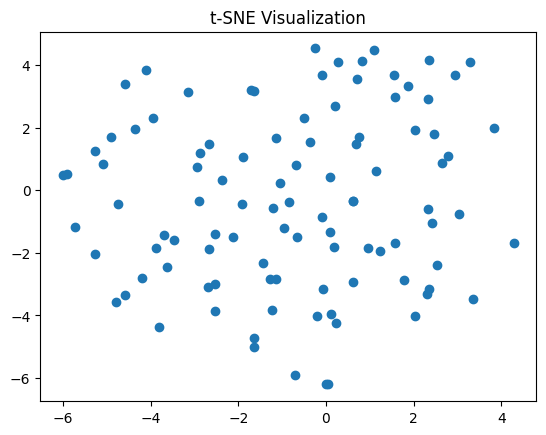

In [5]:
from sklearn.manifold import TSNE

# Reduce to 2D
X_tsne = TSNE(n_components=2, perplexity=30).fit_transform(X)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.title("t-SNE Visualization")
plt.show()

📌 **Effect:**  
- Helps visualize complex high-dimensional data.

---

### ✅ **3. Feature Engineering (Combining Features Smartly)**  
Instead of reducing dimensions, we can **combine existing features** into meaningful new ones.

**🔹 Examples:**
- Instead of using **height & weight separately**, use **BMI = weight / height²**.  
- Combine **age & income** into a **financial stability index**.  

📌 **Effect:**  
- Converts high-dimensional data into meaningful lower-dimensional data.

---

### ✅ **4. Using Algorithms That Handle High-Dimensional Data**  
📌 Some models handle high dimensions **better than others**.

| **Algorithm**           | **Handles High Dimensions?** |
|------------------------|----------------------------|
| **Decision Trees (RF, XGBoost)** | ✅ Yes (Feature selection happens naturally) |
| **SVM (with kernel tricks)** | ✅ Yes (Can map data to lower-dimensional spaces) |
| **k-NN, K-Means** | ❌ No (Distance metrics become meaningless) |

---

## 📊 **5. Real-World Examples of Curse of Dimensionality**  

| **Domain**                 | **Example** |
|---------------------------|------------|
| **Image Processing**       | 1 million pixel values per image (CNNs handle it well). |
| **Text Processing (NLP)**  | Large vocabulary size (TF-IDF, Word Embeddings help reduce dimensions). |
| **Genomics & Healthcare**  | DNA sequences with thousands of features (Feature Selection helps). |

---

## 🏆 **6. Key Takeaways**  
✔ **High-dimensional data is often sparse, making it harder for ML models to generalize.**  
✔ **Distance-based models (KNN, K-Means) suffer the most from high dimensions.**  
✔ **Feature Selection (Variance Threshold, RFE) helps remove irrelevant features.**  
✔ **Dimensionality Reduction (PCA, t-SNE, Autoencoders) can help retain essential features.**  
✔ **Deep Learning (CNNs, Autoencoders) handles high-dimensional data effectively in images & text.**  

💡 **Pro Tip:** Always **check model performance with & without dimensionality reduction** before deciding!

---